<a href="https://colab.research.google.com/github/pranavich18/ML_Labs/blob/main/lab4_mlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Lab 4: Fitting an MLP to regression data

In this lab, you will implement and a train a simple neural network in PyTorch. Then, you will study how the function approximation capabilities of this model are affected by the model width and depth.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

Let's create some regression data using a complicated function. There will be no test data, just the train set that we will try to fit.

Text(0, 0.5, 'y')

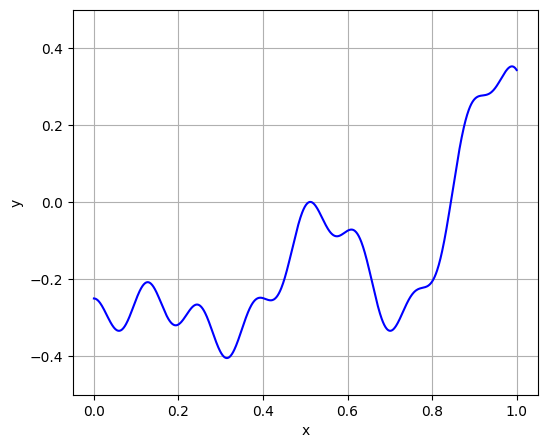

In [2]:
def f(x):
  return 0.2 + 0.4 * x**2 + 0.3 * x * torch.sin(15 * x)+ 0.05 * torch.cos(50*x) - 0.5

x = torch.linspace(0, 1, 1000)
fs = f(x)

_, ax = plt.subplots(1, 1, figsize=(6, 5))

ax.plot(x, fs, "-b")
ax.grid()
ax.set_ylim([-0.5, 0.5])
ax.set_xlabel("x")
ax.set_ylabel("y")


Complete the function below. See the docstring for detailed instructions. Make sure that the training works and you get a reasonable fit when you run the function with the provided parameters.

Sequential(
  (0): Linear(in_features=1, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=1, bias=True)
)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([1000])) that is different to the input size (torch.Size([1000, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Text(0, 0.5, 'y')

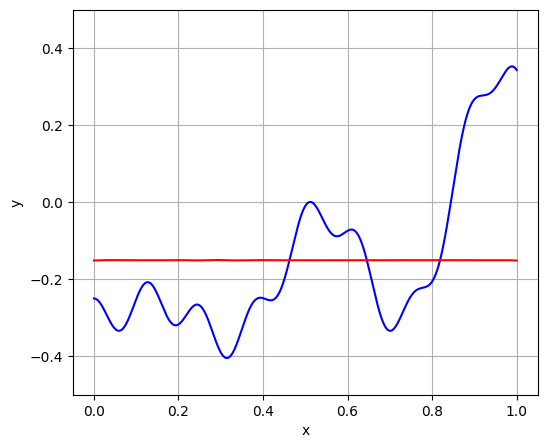

In [4]:
def train_model(
    x: torch.Tensor,
    y: torch.Tensor,
    width: int,
    num_hidden_layers: int,
    epochs: int = 1000,
    activation=nn.ReLU,
    lr: float=0.01,
    ):
  """
    Train a fully connected neural network for regression tasks using PyTorch.

    This function constructs a feedforward neural network with a specified architecture,
    trains it using the Adam optimizer and mean squared error loss, and returns both
    the trained model and its predictions on the input data.

    Architecture:
        - Input layer: Linear(1, width) → Activation
        - Hidden layers: [Linear(width, width) → Activation] × num_hidden_layers
        - Output layer: Linear(width, 1) (no activation)

    The network expects 1-dimensional input features and produces scalar outputs.

    Parameters
    ----------
    x : torch.Tensor
        Input training data of shape (n_samples, 1) or (n_samples,).
        Each sample should contain a single feature value.

    y : torch.Tensor
        Target training labels of shape (n_samples,).
        Ground truth values for the regression task.

    width : int
        Number of neurons in each hidden layer.

    num_hidden_layers : int
        Number of hidden layers in the network (not counting input/output layers).

    epochs : int, optional (default=1000)
        Number of complete passes through the training dataset.

    activation : torch.nn.Module class, optional (default=nn.ReLU)
        Activation function class to use after each linear layer except the output.
        Common choices: nn.ReLU, nn.Sigmoid, nn.Tanh, nn.LeakyReLU.
        Should be passed as a class (not an instance), e.g., nn.ReLU, not nn.ReLU().

    lr : float, optional (default=0.01)
        Learning rate for the Adam optimizer.

    Returns
    -------
    model : torch.nn.Sequential
        The trained neural network model in evaluation mode. Can be used for
        inference on new data via model(new_x).

    final_pred : torch.Tensor
        Model predictions on the input data x, detached from the computation graph.
        Shape: (n_samples,). Useful for immediate visualization or evaluation.

    Training Details
    ----------------
    - Optimizer: Adam
    - Loss function: Mean Squared Error (MSE)

  """
  layers = []
  layers.append(nn.Linear(1, width))
  layers.append(activation())

  for _ in range(num_hidden_layers-1):
    layers.append(nn.Linear(width, width))
    layers.append(activation())

  layers.append(nn.Linear(width, 1))
  model = nn.Sequential(*layers)
  print(model)

  model.train()
  optimizer = torch.optim.Adam(model.parameters(), lr=lr)

  loss_func = nn.MSELoss()

  for epoch in range(epochs):
      optimizer.zero_grad()

      pred = model(x)
      loss = loss_func(pred, y)

      loss.backward()
      optimizer.step()

  model.eval()
  final_pred = model(x).squeeze().detach()
  return model, final_pred


_, y_pred = train_model(x[:, None], fs, width=256, num_hidden_layers=1)


_, ax = plt.subplots(1, 1, figsize=(6, 5))

ax.plot(x, fs, "-b")
ax.plot(x, y_pred, "-r")
ax.grid()
ax.set_ylim([-0.5, 0.5])
ax.set_xlabel("x")
ax.set_ylabel("y")


Now, try the following values of width and depth:
- `num_hidden_layers in [1, 3]`
- `width in [1, 16, 64]`

Sweep both parameters simultaneously, so you have 6 settings in total. Present your results as a $2 \times 3$ grid of plots.

Discuss your results in a few sentences.

In [ ]:
y_preds = {}

for num_hidden_layers in [1, 3]:
  for width in [1, 16, 64]:
    ...

In [ ]:
_, arr = plt.subplots(2, 3, figsize=(15, 10))

...